# **Code of the Practice Session**

In [1]:
import random
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def reward_function(state):
  """
    Reward function takes a state and return
    the possible rewards in that state.
    Note that the reward function is usually given as
    a function of (s, a, s') but here, the rewards only
    depend on the state you land in no matter which action
    you took and which state you came from

  """
  if state=="A":
    return [-1, 0]
  elif state=="B":
    return [0]
  elif state=="C":
    return [0]
  elif state=="D":
    return [1]
  else:
    raise f"state {state} does not exist in state space: {state_space}"

def atree(next_state, action, reward, policy_dist):
  """
    This computes the joint probability of a transitioning
    from state A to any next_state and receiving the reward.
    It's basically the tree of A that we saw in Fig.1.b
  """
  if next_state=="A" and action=="left":
    if reward==0:
      return 0.3*1*policy_dist[action]
    elif reward==-1:
      return 0.7*1*policy_dist[action]
    else :
      return 0

  elif next_state=="B" and action=="right":
    if reward==0:
      return 1*1*policy_dist[action]
    else:
      return 0
  else:
    return 0

def btree(next_state, action, reward, policy_dist):
  """
    This computes the joint probability of a transitioning
    from state B to any next_state and receiving the reward.
    It's basically the tree of B that we saw in Fig.1.b
  """
  if next_state=="A" and action=="left":
    if reward==0:
      return 0.3*1*policy_dist[action]
    elif reward==-1:
      return 0.7*1*policy_dist[action]
    else:
      return 0

  elif next_state=="C" and action=="right":
    if reward==0:
      return 1*1*policy_dist[action]
    else:
      return 0
  else:
    return 0

def ctree(next_state, action, reward, policy_dist):
  """
    This computes the joint probability of a transitioning
    from state C to any next_state and receiving the reward.
    It's basically the tree of C that we saw in Fig.1.b
  """
  if next_state=="A" and action=="left":
    if reward==0:
      return 0.3*0.15*policy_dist[action]
    elif reward==-1:
      return 0.7*0.15*policy_dist[action]
    else:
      return 0
  elif next_state=="B" and action=="left":
    if reward==0:
      return 1.*0.85*policy_dist[action]
    else:
      return 0

  elif next_state=="D" and action=="right":
    if reward==1:
      return 1*1*policy_dist[action]
    else:
      return 0
  else:
    return 0

def dtree(next_state, action, reward, policy_dist):
  """
    No transition from D because it's the final state. Thus probability is 0
  """

  return 0


def transition_probability_function(next_state, reward, state, action, policy_dist):
  """
    Full dynamic of this Markov Decision Process (MDP)
  """
  if state=="A":
     prob = atree(next_state, action, reward, policy_dist)
  elif state=="B":
    prob = btree(next_state, action, reward, policy_dist)
  elif state=="C":
    prob = ctree(next_state, action, reward, policy_dist)
  elif state=="D":
    prob = dtree(next_state, action, reward, policy_dist)
  else:
    raise f"state {state} does not exist in state space: {state_space}"

  return prob

In [30]:
def test(state_space, policy_dist):
  """
    This is a small test to unsure every transition
    sump up to 1 for each state (except D) and action.
    Remember that it's a distribution.
  """
  for state in state_space:
    prob = 0
    for action in policy_dist.keys():
      for next_state in state_space:
        for reward in reward_function(next_state):
          prob += transition_probability_function(next_state, reward, state, action, policy_dist)
    if state=="D":
      assert prob==0, "No transition from D, it's prob must be 0"
      print(f"state {state}: OK")
    else:
      assert prob>=0.99 and prob<=1.01, f"All transition probabilities must sum up to 1 for each s and a,\
                      you have prob: {prob} for state {state}"
      print(f"state {state}, prob: {prob}: OK")


In [31]:
state_space = ["A", "B", "C", "D"]
action_space = ["left", "right"]
policy_distribution = {"left":0.3, "right":0.7}
state_value_dict = {"A":0, "B":0, "C":0, "D":0} # a scalar for each state
previous_state_value_dict = deepcopy(state_value_dict)

test(state_space, policy_distribution)

state A, prob: 1.0: OK
state B, prob: 1.0: OK
state C, prob: 1.0: OK
state D: OK


In [37]:
NUM_ITER = 10
gamma = 0.8
alpha = 1.
alpha_list = np.arange(0, 1, 0.05)
state_value_runs = np.zeros((len(alpha_list), len(state_space)))
for idx, alpha in enumerate(alpha_list):

  state_value_dict = {"A":0, "B":0, "C":0, "D":0} # a scalar for each state
  previous_state_value_dict = deepcopy(state_value_dict)

  # this will hold the old value function
  # when we are computing the new value function. This is called the two arrays
  # method in Sutton & Barto. But you can do with only one value function also
  # which is called the in place method
  # So with two arrays, you have: value(s) = p(s', r|a, s)*[r + old value(s')]
  # And with in-place update, you have: value(s) = p(s', r|a, s)*[r + value(s')]

  # You are free to use whatever method you want, though the in-place update converges
  # faster than the two-arrays version because it immediately uses the value of
  # the state s as long as it become available. whereas with two-arrays, the value
  # array remains fixed for ONE FULL ITERATION !

  # But... we will use the two-arrays version here !!!!!

  policy_distribution = {"left":round(1-alpha, 2), "right":round(alpha, 2)}
  print(f"\n====== Test: {policy_distribution} =======")
  test(state_space, policy_distribution)
  print("========================= Test END! ===========================\n")
  for iter in range(NUM_ITER):
    for state in state_space:
      value = 0 # initliaze the value of the state
      for action in action_space:
        temp_sum = 0
        for next_state in state_space:
          possible_rewards = reward_function(next_state)
          for reward_obtained in possible_rewards:
            next_state_value = previous_state_value_dict[next_state]
            temp_sum += transition_probability_function(next_state, reward_obtained, state, action, policy_distribution)*(reward_obtained + gamma*next_state_value)
        value += policy_distribution[action]*temp_sum

      state_value_dict[state] = round(value, 3)


    state_value_runs[idx] = list(state_value_dict.values())

    print(f"INFO Iteration: {iter}, value of each state is: {state_value_dict}")
    previous_state_value_dict = deepcopy(state_value_dict)


====== Test: {'left': np.float64(1.0), 'right': np.float64(0.0)} =======
state A, prob: 1.0: OK
state B, prob: 1.0: OK
state C, prob: 1.0: OK
state D: OK
========================= Test END! ===========================

INFO Iteration: 0, value of each state is: {'A': np.float64(-0.7), 'B': np.float64(-0.7), 'C': np.float64(-0.105), 'D': np.float64(0.0)}
INFO Iteration: 1, value of each state is: {'A': np.float64(-1.26), 'B': np.float64(-1.26), 'C': np.float64(-0.665), 'D': np.float64(0.0)}
INFO Iteration: 2, value of each state is: {'A': np.float64(-1.708), 'B': np.float64(-1.708), 'C': np.float64(-1.113), 'D': np.float64(0.0)}
INFO Iteration: 3, value of each state is: {'A': np.float64(-2.066), 'B': np.float64(-2.066), 'C': np.float64(-1.471), 'D': np.float64(0.0)}
INFO Iteration: 4, value of each state is: {'A': np.float64(-2.353), 'B': np.float64(-2.353), 'C': np.float64(-1.758), 'D': np.float64(0.0)}
INFO Iteration: 5, value of each state is: {'A': np.float64(-2.582), 'B': np.floa

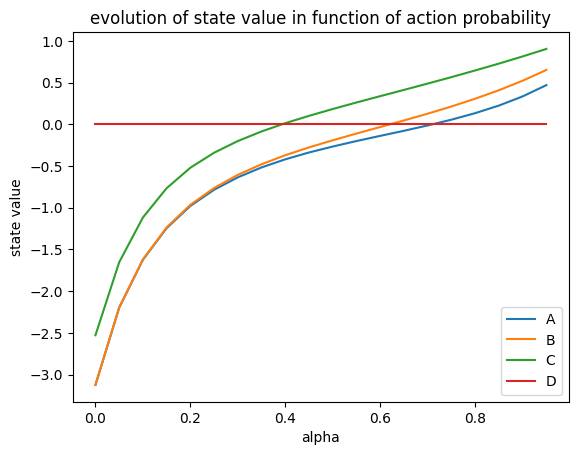

In [33]:
for i in range(len(state_space)):
  plt.plot(alpha_list, state_value_runs[:, i], label=f"{state_space[i]}")

plt.title("evolution of state value in function of action probability")
plt.xlabel("alpha")
plt.ylabel("state value")
plt.legend()

In [46]:
NUM_ITER = 10
alpha = 0.
gamma_list = [0.2, 0.8, 1.] #np.arange(0.2, 1, 0.2)
state_value_runs = np.zeros((len(gamma_list), len(state_space), NUM_ITER))
policy_distribution = {"left":1-alpha, "right":alpha}
for idx, gamma in enumerate(gamma_list):
  state_value_dict = {"A":0, "B":0, "C":0, "D":0} # a scalar for each state
  previous_state_value_dict = deepcopy(state_value_dict) # this will hold the
  for iter in range(NUM_ITER):
    for state in state_space:
      value = 0 # initliaze the value of the state
      for action in action_space:
        temp_sum = 0
        for next_state in state_space:
          possible_rewards = reward_function(next_state)
          for reward_obtained in possible_rewards:
            next_state_value = previous_state_value_dict[next_state]
            temp_sum += transition_probability_function(next_state, reward_obtained, state, action, policy_distribution)*(reward_obtained + gamma*next_state_value)
        value += policy_distribution[action]*temp_sum

      state_value_dict[state] = round(value, 3)


      state_value_runs[idx, :, iter] = list(state_value_dict.values())

    print(f"INFO Iteration: {iter}, value of each state is: {state_value_dict}")
    previous_state_value_dict = deepcopy(state_value_dict)

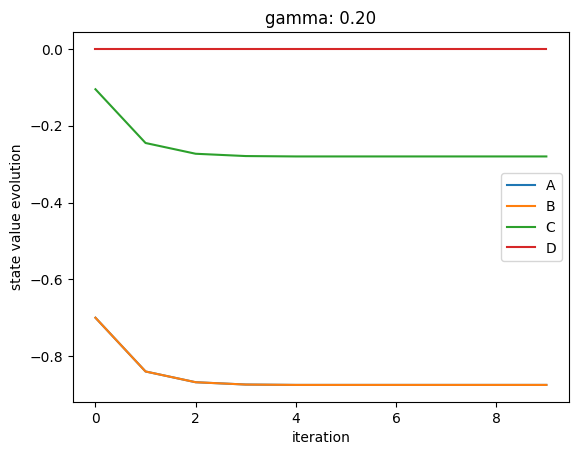

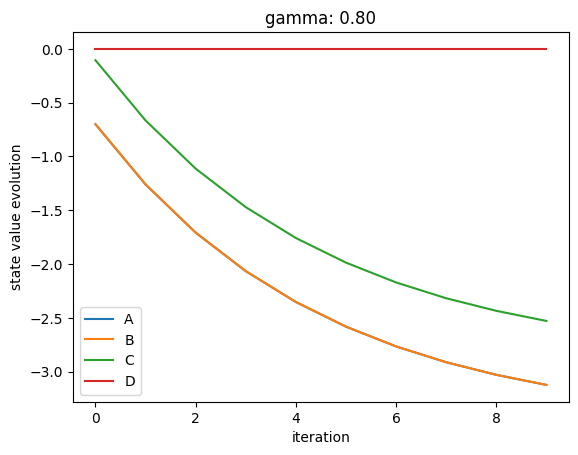

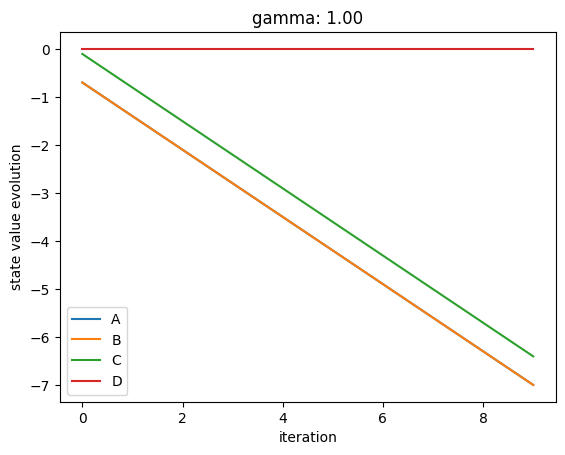

In [47]:
for idx, gamma in enumerate(gamma_list):
  plt.figure()
  plt.title(f"gamma: {gamma:.02f}")
  for i in range(len(state_space)):
    plt.plot(np.arange(len(state_value_runs[idx, i, :])), state_value_runs[idx, i, :], label=f"{state_space[i]}")
  plt.xlabel("iteration")
  plt.ylabel("state value evolution")
  plt.legend()
